# Laboratory: Windowing in Spectral Analysis (FFT)

**Topic:** Window functions and why we apply them in practice.

## Learning outcomes
After this lab you should be able to:
- Explain why a finite observation causes **spectral leakage**
- Compare common windows (Rectangular, Hann, Hamming, Blackman, Kaiser)
- Choose an appropriate window for a given goal:
  - **Detecting weak tones near strong tones** (high dynamic range)
  - **Separating close tones** (frequency resolution)
- Interpret FFT magnitude plots (linear and dB), including leakage and main-lobe width
- Apply a simple **coherent gain** correction when needed (bin-centered tones)

---

### Rules of thumb (what to remember)
- **Rectangular window** (no windowing): narrowest main-lobe (best resolution), **worst leakage** (high sidelobes)
- **Stronger tapering** (e.g., Blackman): lower sidelobes (better weak-tone detection), **wider main-lobe** (worse separation of close tones)
- **Zero-padding** makes plots smoother but **does not increase true resolution**


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Make plots a bit larger by default
plt.rcParams["figure.figsize"] = (9, 4.5)

def db(x, floor_db=-160.0):
    """Magnitude to dB with floor to avoid -inf."""
    x = np.asarray(x)
    mag = np.abs(x)
    mag = np.maximum(mag, 10**(floor_db/20))
    return 20*np.log10(mag)

def nextpow2(n):
    return 1 << int(np.ceil(np.log2(int(n))))

def make_window(name, N, beta=8.0):
    """Return common windows. Kaiser uses the 'beta' parameter."""
    name = name.lower()
    if name in ["rect", "rectangular", "boxcar", "none"]:
        return np.ones(N)
    if name == "hann":
        return np.hanning(N)
    if name == "hamming":
        return np.hamming(N)
    if name == "blackman":
        return np.blackman(N)
    if name == "kaiser":
        return np.kaiser(N, beta)
    raise ValueError(f"Unknown window: {name}")

def coherent_gain(w):
    """Coherent gain Gc = mean(w). Used for bin-centered tone amplitude correction."""
    w = np.asarray(w)
    return np.sum(w) / len(w)

def fft_mag(x, fs, nfft=None):
    """One-sided FFT magnitude and frequency axis."""
    x = np.asarray(x)
    N = len(x)
    if nfft is None:
        nfft = nextpow2(N) * 8  # smoother curves; doesn't increase true resolution
    X = np.fft.rfft(x, n=nfft)
    f = np.fft.rfftfreq(nfft, d=1/fs)
    return f, np.abs(X)

def plot_time(x, fs, title="", nshow=400):
    N = len(x)
    n = np.arange(N)
    nshow = min(nshow, N)
    t = n[:nshow] / fs
    plt.figure()
    plt.plot(t, x[:nshow])
    plt.grid(True)
    plt.xlabel("Time [s]")
    plt.ylabel("Amplitude")
    plt.title(title)
    plt.show()

def plot_windows(N=256, beta=8.0):
    names = ["rectangular", "hann", "hamming", "blackman", "kaiser"]
    n = np.arange(N)
    plt.figure()
    for nm in names:
        w = make_window(nm, N, beta=beta)
        plt.plot(n, w, label=(nm if nm != "kaiser" else f"kaiser (beta={beta})"))
    plt.grid(True)
    plt.xlabel("Sample index n")
    plt.ylabel("w[n]")
    plt.title("Common windows (time domain)")
    plt.legend()
    plt.show()

def plot_spectra_for_windows(x, fs, N, win_list, title="", fmax=None, normalize_peak=True, beta=8.0):
    """Plot normalized spectra (dB) for a set of windows."""
    plt.figure()
    for nm in win_list:
        w = make_window(nm, N, beta=beta)
        f, X = fft_mag(x*w, fs)
        Y = X
        if normalize_peak:
            Y = Y / np.max(Y)
        plt.plot(f, db(Y), label=(nm if nm != "kaiser" else f"kaiser(beta={beta})"))
    plt.grid(True)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("Magnitude [dB]")
    if fmax is not None:
        plt.xlim(0, fmax)
    plt.ylim(-140, 5)
    plt.title(title)
    plt.legend()
    plt.show()

def mixed_signal(fs, N, tones, noise_std=0.0, seed=0):
    """Create a mixed signal: sum of cosines + optional white noise.
    tones: list of dicts with keys {A, f, phi(optional)}
    """
    rng = np.random.default_rng(seed)
    n = np.arange(N)
    x = np.zeros(N, dtype=float)
    for t in tones:
        A = float(t.get("A", 1.0))
        f = float(t.get("f", 100.0))
        phi = float(t.get("phi", 0.0))
        x += A * np.cos(2*np.pi*f*n/fs + phi)
    if noise_std > 0:
        x += rng.normal(0.0, noise_std, size=N)
    return x


## Why windowing?

In an FFT we always analyze a **finite-length block** of samples.  
That is equivalent to multiplying the (infinite) signal by a window:

$$
x_\text{meas}[n] = x[n] \cdot w[n]
$$

- If we do nothing special, the window is **rectangular** (cutting the signal abruptly).
- Multiplication in time corresponds to **convolution in frequency**:

$$
X_\text{meas}(e^{j\omega}) = X(e^{j\omega}) * W(e^{j\omega})
$$

The rectangular window has high sidelobes in its spectrum, so its convolution spreads energy into many bins.  
This is **spectral leakage**.

Windowing reduces leakage by tapering the signal near the edges (making the discontinuity smaller).


## 1) Look at windows in time domain

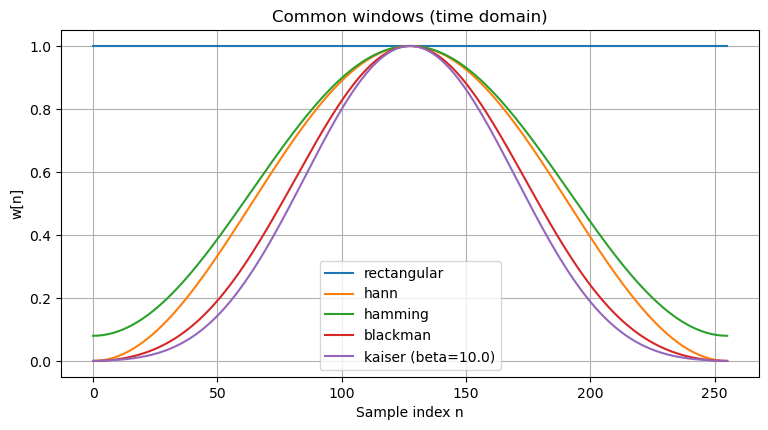

In [8]:
plot_windows(N=256, beta=10.0)

## 2) Spectral leakage demo: bin-centered vs off-bin tone

We compare:
- **Bin-centered** tone: frequency exactly equals an FFT bin -> leakage is minimal
- **Off-bin** tone: frequency is between bins -> leakage appears

Then we compare windows.


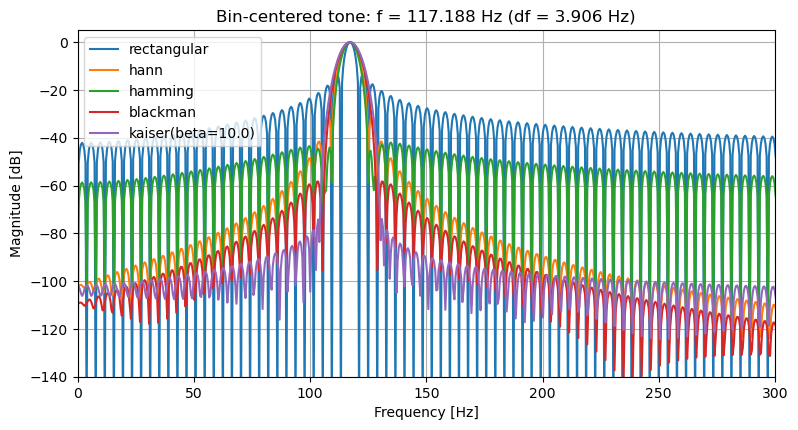

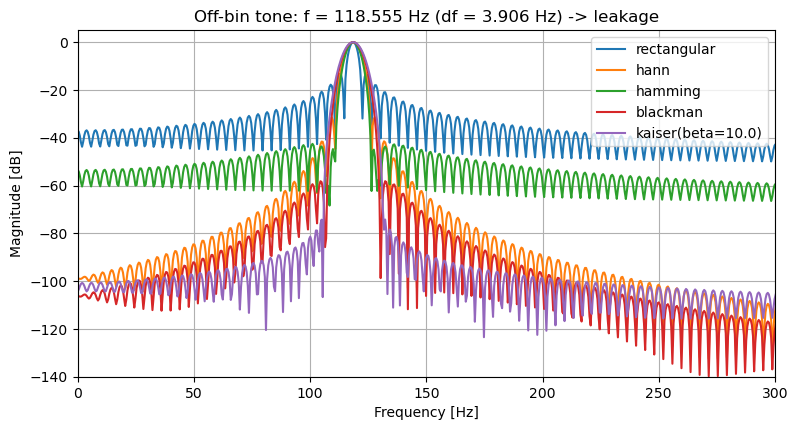

In [9]:
fs = 1000.0
N  = 256
df = fs / N

k0 = 30
f_bin = k0 * df
f_off = (k0 + 0.35) * df  # between FFT bins

n = np.arange(N)
A = 1.0
x_bin = A*np.cos(2*np.pi*f_bin*n/fs)
x_off = A*np.cos(2*np.pi*f_off*n/fs)

win_list = ["rectangular", "hann", "hamming", "blackman", "kaiser"]

plot_spectra_for_windows(
    x_bin, fs, N, win_list,
    title=f"Bin-centered tone: f = {f_bin:.3f} Hz (df = {df:.3f} Hz)",
    fmax=300, beta=10.0
)

plot_spectra_for_windows(
    x_off, fs, N, win_list,
    title=f"Off-bin tone: f = {f_off:.3f} Hz (df = {df:.3f} Hz) -> leakage",
    fmax=300, beta=10.0
)


### Questions (write short answers)
1. In the **bin-centered** case, do you see leakage? Why/why not?
2. In the **off-bin** case, which window produces the *lowest sidelobes*?
3. Which window produces the *narrowest main-lobe*? What does that mean for frequency resolution?

### Answers (model solution)
1. **Bin-centered:** ideally *no* leakage (almost all energy stays in one FFT bin pair), because the sampled sinusoid completes an integer number of cycles in the record, so it matches the DFT basis exactly. Any tiny spreading you see is usually numerical/plot scaling.
2. **Off-bin:** the **Blackman** and **Kaiser (beta=10)** windows give the **lowest sidelobes** (best leakage suppression). Rectangular is worst.
3. **Narrowest main-lobe:** **Rectangular**. A narrower main-lobe means better ability to **separate close frequencies** (higher frequency resolution), but it comes with much higher sidelobes (more leakage).


## 3) Trade-off visualization: main-lobe width vs sidelobes (window spectra)

A useful way to understand the trade-off is to look at the FFT of the **window itself**.


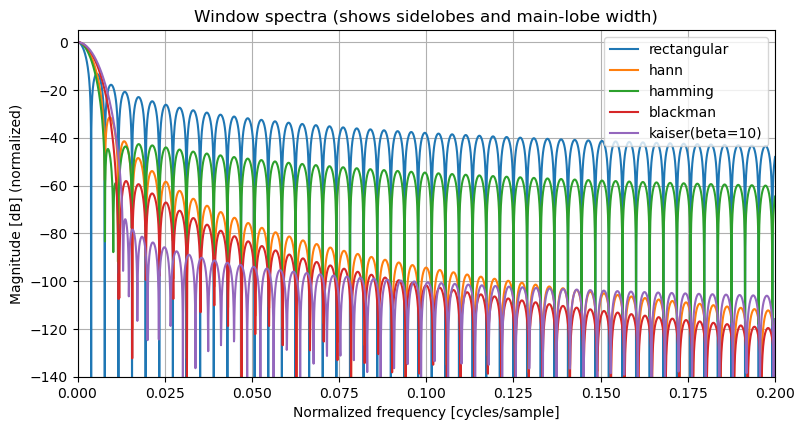

In [10]:
fs = 1.0
N = 256
win_list = ["rectangular", "hann", "hamming", "blackman", "kaiser"]

# Window "signal" is w[n]; show its spectrum around DC
plt.figure()
for nm in win_list:
    w = make_window(nm, N, beta=10.0)
    f, W = fft_mag(w, fs, nfft=16384)
    # Normalize to 0 dB at DC peak for comparison
    plt.plot(f, db(W/np.max(W)), label=(nm if nm != "kaiser" else "kaiser(beta=10)"))
plt.grid(True)
plt.xlabel("Normalized frequency [cycles/sample]")
plt.ylabel("Magnitude [dB] (normalized)")
plt.title("Window spectra (shows sidelobes and main-lobe width)")
plt.xlim(0, 0.2)
plt.ylim(-140, 5)
plt.legend()
plt.show()


## 4) Mixed signal: **three** tones close in frequency (similar amplitudes)

This scenario focuses on **frequency resolution**: can you separate **three** close components?

Try to decide which window gives you the clearest separation of all three peaks.


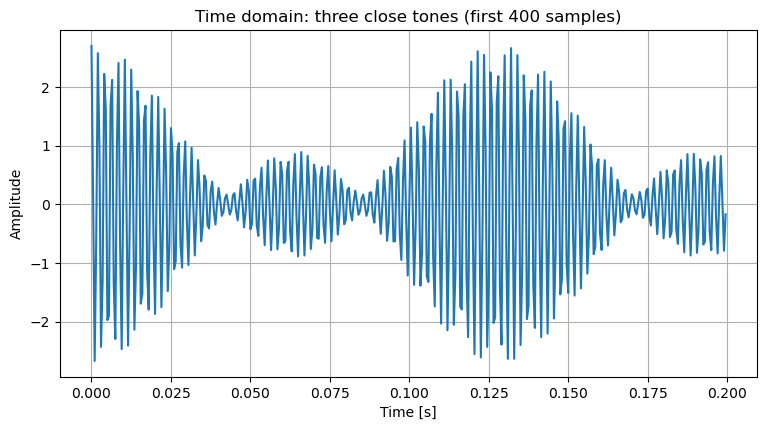

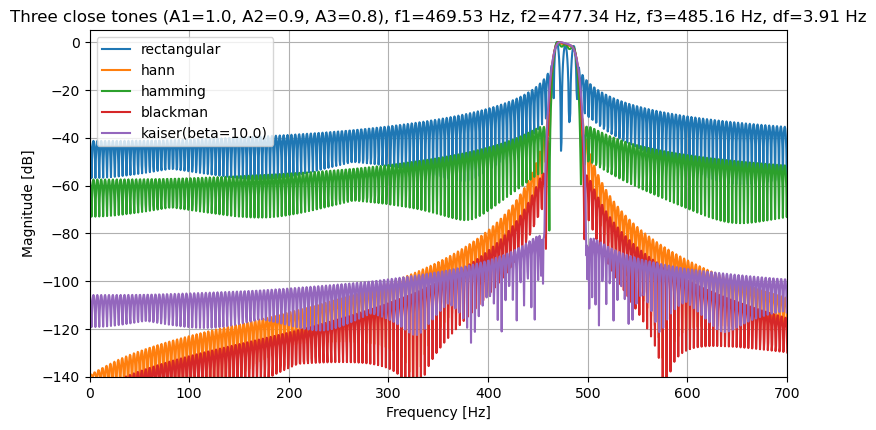

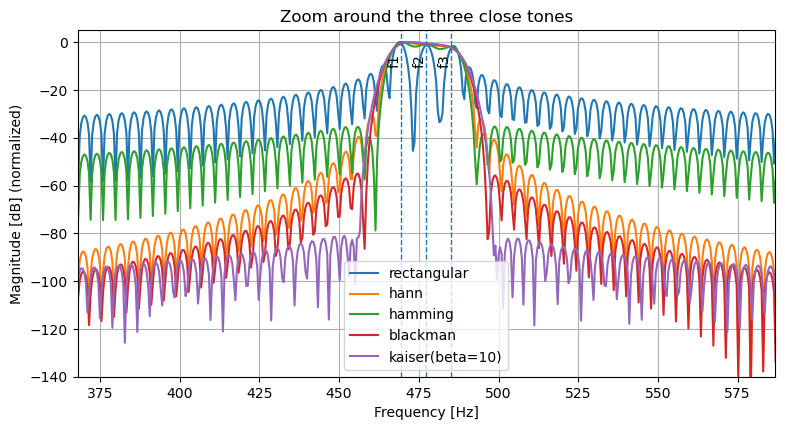

In [11]:
fs = 2000.0
N  = 512
df = fs / N

# Three close tones, similar amplitudes (resolution-focused)
k1 = 120
f1 = (k1 + 0.20) * df     # slightly off-bin
f2 = f1 + 2.0*df          # 2 bins away
f3 = f2 + 2.0*df          # another 2 bins away

A1 = 1.0
A2 = 0.9
A3 = 0.8

x = mixed_signal(
    fs, N,
    tones=[{"A":A1, "f":f1}, {"A":A2, "f":f2}, {"A":A3, "f":f3}],
    noise_std=0.0
)

plot_time(x, fs, title="Time domain: three close tones (first 400 samples)", nshow=400)

win_list = ["rectangular", "hann", "hamming", "blackman", "kaiser"]
plot_spectra_for_windows(
    x, fs, N, win_list,
    title=(f"Three close tones (A1={A1}, A2={A2}, A3={A3}), "
           f"f1={f1:.2f} Hz, f2={f2:.2f} Hz, f3={f3:.2f} Hz, df={df:.2f} Hz"),
    fmax=700, beta=10.0
)

# Zoom around the three peaks
f_center = (f1 + f3)/2
span_hz = 28*df

plt.figure()
for nm in win_list:
    w = make_window(nm, N, beta=10.0)
    f, X = fft_mag(x*w, fs)
    Y = X/np.max(X)
    plt.plot(f, db(Y), label=(nm if nm != "kaiser" else "kaiser(beta=10)"))

# Mark true tone frequencies
for ff, lab in [(f1, "f1"), (f2, "f2"), (f3, "f3")]:
    plt.axvline(ff, linestyle="--", linewidth=1)
    plt.text(ff, -5, lab, rotation=90, va="top", ha="right")

plt.grid(True)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB] (normalized)")
plt.title("Zoom around the three close tones")
plt.xlim(f_center - span_hz, f_center + span_hz)
plt.ylim(-140, 5)
plt.legend()
plt.show()


### Questions
1. Which window separates **all three** close tones best? Explain using **main-lobe width**.
2. Which window shows the least leakage outside the peak region? Explain using **sidelobes**.
3. Reduce/increase the tone spacing (e.g., 2·df -> 1·df or 4·df). At what spacing do the three peaks become hard to distinguish for each window?
4. Increase **N** (e.g., 512 -> 2048) and repeat. What changes? Why?

### Answers (model solution)
1. **Best separation (resolution):** usually the **rectangular** window separates three close tones best because it has the **narrowest main-lobe**. (Hann/Hamming are wider; Blackman/Kaiser are widest and may merge peaks.)
2. **Least leakage (dynamic range):** **Blackman** and **Kaiser (beta=10)** show the least leakage far away from the peaks because they have **much lower sidelobes**.
3. **Spacing where peaks become hard to distinguish (typical trend):**
   - Rectangular: starts getting difficult around **~1–2·df** spacing (especially when tones are slightly off-bin).
   - Hann / Hamming: often needs **~2–3·df** spacing.
   - Blackman / Kaiser(beta≈10): often needs **~3–4·df or more** spacing.
   (Exact numbers depend on amplitudes, off-bin offsets, and plotting scale.)
4. **Increasing N:** \(df = f_s/N\) decreases, so the same Hz spacing corresponds to **more FFT bins**, and the **main-lobe width in Hz shrinks** (better true resolution). Peaks become easier to distinguish because you observed a longer time record.


## 5) High dynamic range: strong tone + weak tone nearby

Now the goal is **detection**: can you see a weak component that is close to a strong one?

This is where low-sidelobe windows often help a lot.


df=1.953 Hz, f1=391.113 Hz, f2=396.973 Hz, separation=5.859 Hz, A2/A1=0.010 (-40 dB)


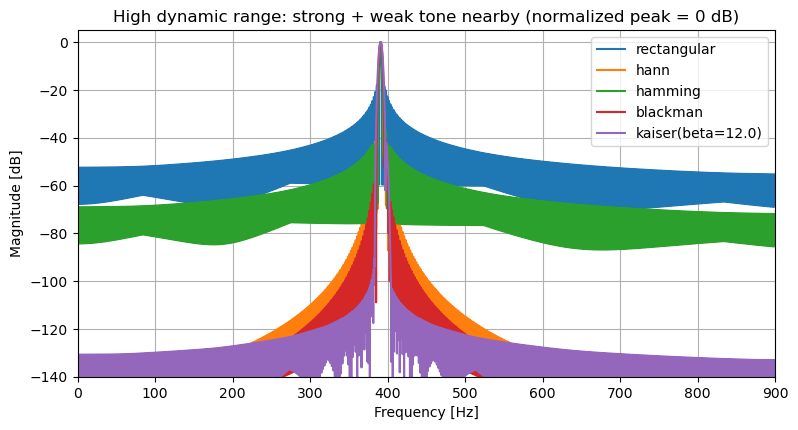

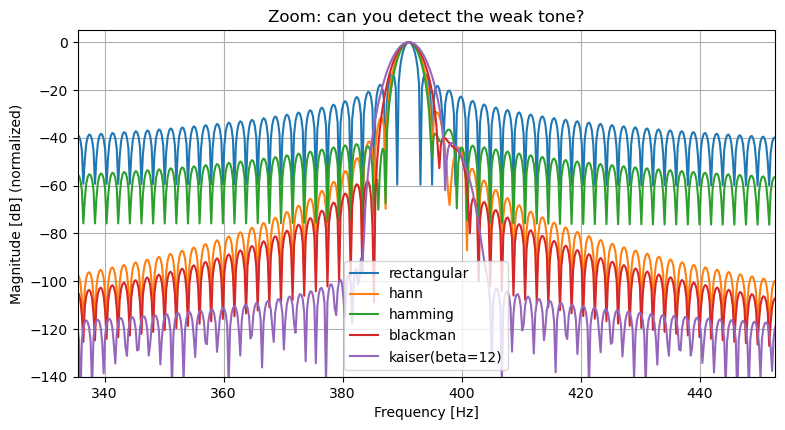

In [12]:
fs = 2000.0
N  = 1024
df = fs / N

# Strong tone slightly off-bin
k1 = 200
f1 = (k1 + 0.25) * df
A1 = 1.0

# Weak tone near the strong one
f2 = f1 + 3*df     # 3 bins away
A2 = 0.01          # -40 dB relative

x = mixed_signal(fs, N, tones=[{"A":A1, "f":f1}, {"A":A2, "f":f2}], noise_std=0.0)

print(f"df={df:.3f} Hz, f1={f1:.3f} Hz, f2={f2:.3f} Hz, separation={f2-f1:.3f} Hz, A2/A1={A2/A1:.3f} (-40 dB)")

win_list = ["rectangular", "hann", "hamming", "blackman", "kaiser"]

# Wide view
plot_spectra_for_windows(
    x, fs, N, win_list,
    title="High dynamic range: strong + weak tone nearby (normalized peak = 0 dB)",
    fmax=900, beta=12.0
)

# Zoom around strong tone region to see whether weak tone is visible
f_center = (f1 + f2)/2
span_hz = 30*df
plt.figure()
for nm in win_list:
    w = make_window(nm, N, beta=12.0)
    f, X = fft_mag(x*w, fs)
    Y = X/np.max(X)
    plt.plot(f, db(Y), label=(nm if nm != "kaiser" else "kaiser(beta=12)"))
plt.grid(True)
plt.xlabel("Frequency [Hz]")
plt.ylabel("Magnitude [dB] (normalized)")
plt.title("Zoom: can you detect the weak tone?")
plt.xlim(f_center - span_hz, f_center + span_hz)
plt.ylim(-140, 5)
plt.legend()
plt.show()


### Questions
1. For which windows is the weak tone clearly visible? For which is it hidden?
2. Explain your observation using the concept of **sidelobe level**.
3. Try changing the weak tone amplitude from -40 dB to -60 dB (A2 = 0.001). Which window works best now?

### Answers (model solution)
1. The weak tone is most clearly visible with **Blackman** and **Kaiser(beta=10)**; it is most often hidden with **rectangular** (and sometimes Hann/Hamming if the strong-tone leakage is still high near the weak tone).
2. Reason: the strong tone creates sidelobes (leakage). Low-sidelobe windows suppress that leakage so the noise/leakage floor drops and the weak tone emerges.
3. At **-60 dB** weak tone, **Kaiser(beta=10)** (and often Blackman) tends to work best because it gives the **lowest sidelobe floor** among the tested windows (at the expense of wider peaks).


## 6) Optional: add noise

Real measurements include noise. Add noise and see how it interacts with leakage.


In [ ]:
fs = 2000.0
N  = 1024
df = fs / N

k1 = 200
f1 = (k1 + 0.25) * df
A1 = 1.0

f2 = f1 + 3*df
A2 = 0.01  # -40 dB

noise_std = 0.05  # try 0.0, 0.02, 0.05, 0.1
x = mixed_signal(fs, N, tones=[{"A":A1, "f":f1}, {"A":A2, "f":f2}], noise_std=noise_std, seed=1)

print(f"noise_std={noise_std}, df={df:.3f} Hz, f1={f1:.3f} Hz, f2={f2:.3f} Hz")

win_list = ["rectangular", "hann", "hamming", "blackman", "kaiser"]

plot_spectra_for_windows(
    x, fs, N, win_list,
    title="Strong+weak tones with noise (normalized peak = 0 dB)",
    fmax=900, beta=12.0
)


## 7) Practical note: amplitude bias and coherent gain

Windowing changes amplitude estimates because the average of the window is less than 1.
For a **bin-centered** tone, a simple correction is division by the **coherent gain**:

\[
G_c = \frac{1}{N}\sum_{n=0}^{N-1} w[n]
\]

This section demonstrates the effect.


In [ ]:
fs = 1000.0
N  = 256
df = fs / N
k0 = 40
f0 = k0 * df  # bin-centered
A  = 0.7

n = np.arange(N)
x = A*np.cos(2*np.pi*f0*n/fs)

win_list = ["rectangular", "hann", "hamming", "blackman", "kaiser"]

measured = []
corrected = []
gains = []

for nm in win_list:
    w = make_window(nm, N, beta=10.0)
    Gc = coherent_gain(w)
    gains.append(Gc)

    f, X = fft_mag(x*w, fs, nfft=N)  # use N so bin aligns exactly
    peak = X[k0]
    measured.append(peak)
    corrected.append(peak / Gc)

print("Window          Gc (mean)    measured_peak    corrected_peak")
for nm, Gc, m, c in zip(win_list, gains, measured, corrected):
    tag = nm if nm != "kaiser" else "kaiser(beta=10)"
    print(f"{tag:14s} {Gc:10.4f} {m:15.5f} {c:16.5f}")

# Bar plot
idx = np.arange(len(win_list))
plt.figure()
plt.bar(idx - 0.15, measured, width=0.3, label="Measured (windowed)")
plt.bar(idx + 0.15, corrected, width=0.3, label="Corrected by 1/Gc")
plt.xticks(idx, [nm if nm != "kaiser" else "kaiser" for nm in win_list])
plt.ylabel("Amplitude (arbitrary FFT scale)")
plt.title("Coherent gain correction for a bin-centered tone")
plt.grid(True)
plt.legend()
plt.show()


# Student assignment (deliverables)

Submit a short report (1–3 pages) answering:

1. Explain spectral leakage in your own words. Why does it happen?
2. For a **strong+weak** tone mixture:
   - Which window helps detect the weak tone best?
   - What is the trade-off you pay for that choice?
3. For **two close tones of similar amplitude**:
   - Which window gives best separation?
   - How does changing N affect your conclusion?
4. Provide at least two plots that support your answers (with labels and dB scale).

**Bonus:** Use a Kaiser window and tune `beta` to improve weak-tone detection. Explain what changes as `beta` increases.
